In [1]:
import sys
import introns
import importlib
import warnings
import pickle

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.utils import class_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, precision_recall_fscore_support, multilabel_confusion_matrix, confusion_matrix

importlib.reload(introns)

<module 'introns' from '/home/semik/projekty/ml_attempts/noncanonical_introns_master/introns.py'>

In [2]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, RidgeClassifier, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [3]:
genome, genes = introns.HELP_load_default_genome_genes()

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 364.31it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


In [4]:
introns_NK, introns_K, introns_I = introns.get_introns_demulti(genes, if_halfway=True)

Intron_K 348
Intron_NK 325
intron_I 7


In [5]:
def introns_seqs_stats(introns_list, introns_name):
        
    baseY = {'C', 'T'}
    baseR = {'A', 'G'}

    e_y_cnt, i_r_cnt, i_C_cnt, i_A_cnt, i_G_cnt, i_CAG_cnt, i_y_cnt, e_r_cnt = 0, 0, 0, 0, 0, 0, 0, 0
    for intron in introns_list:
        c, a, g = False, False, False
        if intron.prev_exon.sequence[-1] in baseY:
            e_y_cnt += 1
        if intron.sequence[0] in baseR:
            i_r_cnt += 1
        if intron.sequence[3] == 'C' and intron.sequence[-6] == 'G':
            c = True
            i_C_cnt += 1
        if intron.sequence[4] == 'A' and intron.sequence[-7] == 'T':
            a = True
            i_A_cnt += 1
        if intron.sequence[5] == 'G' and intron.sequence[-8] == 'C':
            g = True
            i_G_cnt += 1
        if c and a and g:
            i_CAG_cnt += 1
        if intron.sequence[-1] in baseY:
            i_y_cnt += 1
        if intron.next_exon.sequence and intron.next_exon.sequence[0] in baseR:
            e_r_cnt += 1

    tot = len(introns_list)
    print("\t", introns_name)
    print('total', tot)
    print('eY| i', e_y_cnt/tot)
    print('e |Ri', i_r_cnt/tot)
    print('C-G', i_C_cnt/tot)
    print('A-T', i_A_cnt/tot)
    print('G-C', i_G_cnt/tot)
    print('CAG - CTG', i_CAG_cnt/tot)
    print('iY| e', i_y_cnt/tot)
    print('i |Re', e_r_cnt/tot)
    
    return

In [6]:
introns_seqs_stats(introns_NK, "introns NK")
introns_seqs_stats(introns_K, "introns K")
introns_seqs_stats(introns_I, "introns I")

	 introns NK
total 325
eY| i 0.7415384615384616
e |Ri 0.916923076923077
C-G 0.7107692307692308
A-T 0.5907692307692308
G-C 0.7384615384615385
CAG - CTG 0.4307692307692308
iY| e 0.7569230769230769
i |Re 0.8215384615384616
	 introns K
total 348
eY| i 0.06609195402298851
e |Ri 1.0
C-G 0.014367816091954023
A-T 0.014367816091954023
G-C 0.06321839080459771
CAG - CTG 0.0
iY| e 0.0
i |Re 0.7528735632183908
	 introns I
total 7
eY| i 0.42857142857142855
e |Ri 1.0
C-G 0.8571428571428571
A-T 0.7142857142857143
G-C 0.5714285714285714
CAG - CTG 0.42857142857142855
iY| e 0.42857142857142855
i |Re 1.0


In [7]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
introns_variants, true_classes = [], []

# introny NK - 1
# introny I i inne pozycje - 0

for intron_obj in introns_NK:
    introns_variants.append(introns.compute_intron_characteristics(intron_obj))
    true_classes.append(1)
    for var in intron_obj.variations:
        introns_variants.append(introns.compute_intron_characteristics(var))
        true_classes.append(0)
        
for intron_obj in introns_I:
    introns_variants.append(introns.compute_intron_characteristics(intron_obj))
    true_classes.append(0)
    for var in intron_obj.variations:
        introns_variants.append(introns.compute_intron_characteristics(var))
        true_classes.append(0)

print(len(introns_NK)+len(introns_I))
print(len(introns_variants), len(true_classes))

introns_characteristics = pd.DataFrame(introns_variants,
                                       columns = ['eY| i', 'e |Ri', 'C-G', 'A-T', 'G-C',
                                                  'CAG - CGT', 'iY| e', 'i |Re'])
X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, true_classes,
                                                    test_size=0.3, random_state=420) #, stratify=true_classes)

332
941 941


In [12]:
X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, true_classes,
                                                    train_size=0.1, test_size=0.03, random_state=420,
                                                    #stratify=true_classes
                                                    )

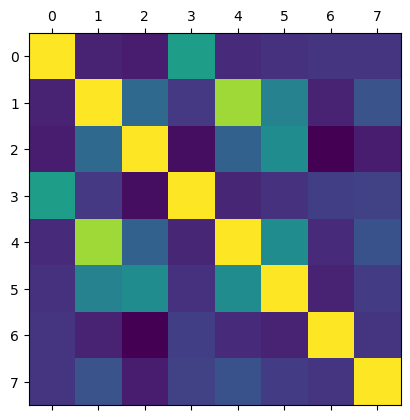

In [13]:
import seaborn as sns
df = pd.DataFrame(introns_characteristics)
df_c = df.corr()
plt.matshow(df_c)
plt.show()

In [14]:
print(f'''
{introns_characteristics.columns[1]}
{introns_characteristics.columns[2]}
{introns_characteristics.columns[6]}
''')


e |Ri
C-G
iY| e



## Classifier 1 - XGBoost

In [16]:
from xgboost import XGBClassifier


parameters={'booster':['gbtree', 'gblinear', 'dart'],
            'sampling_method':['uniform', 'gradient_based'],
            'importance_type':['gain', 'weight', 'cover', 'total_gain', 'total_cover'],
            'enable_categorical':[True, False],
            'tree_method':['approx', 'auto', 'exact', 'hist']}



#clf = XGBClassifier()
clf = xgb.XGBClassifier(eval_metric='aucpr', verbosity=0)
clf = GridSearchCV(clf, parameters, verbose=3)
clf.fit(X_train, y_train)
y_predicted = clf.predict(X_test)
print(classification_report(y_test, y_predicted))
print(confusion_matrix(y_test, y_predicted), "\n\n")

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
[CV 1/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=approx;, score=0.632 total time=  55.4s
[CV 2/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=approx;, score=0.684 total time=  50.2s
[CV 3/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=approx;, score=0.737 total time=  33.2s
[CV 4/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=approx;, score=0.632 total time=  50.6s
[CV 5/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=approx;, score=0.611 total time=  60.0s
[CV 1/5] END booster=gbtree, enable_categorical=True, importance_type=gain, sampling_method=uniform, tree_method=auto;, score=0.632 total time=  31.9s
[CV 2/5] END booster

/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
450 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/xgboost/core.py", line 730, in inner_f
    return func(**kwargs)
  File "/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/xgboost/sklearn.py", line 1497, in fit
    

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        22
           1       0.43      0.43      0.43         7

    accuracy                           0.72        29
   macro avg       0.62      0.62      0.62        29
weighted avg       0.72      0.72      0.72        29

[[18  4]
 [ 4  3]] 




## Classifier 2 - sklearn Gaussian Process

In [ ]:
# uczenie klasyfikatora
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

clf = GaussianProcessClassifier(1.0 * RBF(1.0))
clf.fit(X_train, y_train)
y_test_predicted = clf.predict(X_test)
print(classification_report(y_test, y_test_predicted))


## Classifiers 3+ - sklearn multiple types

In [ ]:
names = [
    "Ridge Classifier",
    "Linear Prediction",
    "Logistic Regression",
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    RidgeClassifier(),
    SGDClassifier(loss='log_loss'),
    LogisticRegression(random_state=0),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, probability=True),
    SVC(gamma=2, C=1, probability=True),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

In [ ]:
for name, clf in list(zip(names, classifiers)):
    clf.fit(X_train, y_train)
    y_predicted = clf.predict(X_test)
    print(name, "\n", classification_report(y_test, y_predicted))
    print(confusion_matrix(y_test, y_predicted), "\n\n")

#### Ridge Classifier, Logistic Regression, Gaussian Process, Neural Net, AdaBoost have almost the same statistics.

#### I choose the Ridge Regression classifier for now

## Checking position finding

In [ ]:
correct_primary_pos, correct_variations, correct_full = 0, 0, 0
incorrect_primary_pos_list, incorrect_variations_list, incorrect_full_list = [], [], []
for intron in introns_NK:
    v1, v2 = False, False
    print(intron.ML_is_nonconventional, [v.ML_is_nonconventional for v in intron.variations])
    if intron.ML_is_nonconventional:
        v1 = True
        correct_primary_pos +=1
    if True not in [v.ML_is_nonconventional for v in intron.variations]:
        v2 = True
        correct_variations += 1
    if v1 and v2:
        correct_full +=1
    elif v1 and not v2:
        incorrect_variations_list.append(intron)
    elif not v1 and v2:
        incorrect_primary_pos_list.append(intron)
    else: #not v1 and not v2
        incorrect_full_list.append(intron)
print((correct_primary_pos, correct_variations, correct_full), len(introns_NK), correct_full/len(introns_NK)*100)
    

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(["""primary position
         correctly identified
         as nk""",
         """no variant
         is classified
         as nk""",
         """primary position
         is the only out of
         all variants to
         be classified as nk""",
         "# of all introns"],
        [correct_primary_pos, correct_variations, correct_full, len(introns_NK)])
for i, n in enumerate([correct_primary_pos, correct_variations, correct_full, len(introns_NK)]):
        plt.text(i-0.25, n+5, "{:.2f}% ({})".format(n/len(introns_NK)*100, n))
plt.title("Classifying introns' positions with a ridge regression classifier")
#plt.savefig("classifying_variants.png", transparent=False, facecolor='1')
plt.show()

In [ ]:
### NOT SAVING FOR NOW

# f = "13_07_wrongly_classified_introns.fasta"
# file = open(f, 'w')
# file.write("#>intron name || probability of being nk (how decided) || how was it classified\n")
# file.write("#prev exon sequence (10), intron sequence, next exon sequence (10)\n")
# file.write("#primary not nk - primary position is not classified as nk\n")
# file.write("#variants nk - at least one of the variants is classified as nk\n")
# for intron_list, text in [(incorrect_primary_pos_list, "primary not nk"),
#                           (incorrect_variations_list, "variants nk"),
#                           (incorrect_full_list,"primary not nk and variant nk")]:
#     for intron in intron_list:
#         s = intron.prev_exon.sequence[-10:] + intron.sequence + intron.next_exon.sequence[:10]
#         file.write(">%s || %s (%s) || %s \n%s\n" %(intron.__str__(), intron.ML_nonconv_proba, "is nk" if intron.ML_is_nonconventional else "not nk", text, s))
#         if text != "primary not nk":
#             for var in intron.variations:
#                 sv = var.prev_exon.sequence[-10:] + var.sequence + var.next_exon.sequence[:10]
#                 file.write(">%s var || %s (%s)\n%s\n" %(var.__str__(), var.ML_nonconv_proba, "is nk" if var.ML_is_nonconventional else "not nk", sv))
# file.close()

In [ ]:
plt.figure(figsize=(10,5))
variants_probs = [[i.ML_nonconv_proba]+[v.ML_nonconv_proba for v in i.variations] for i in incorrect_variations_list]
variants_probs = [item for sublist in variants_probs for item in sublist]
plt.hist(variants_probs, bins=20);
plt.title("""Distribution of decision function values in introns
          that have variants predicted as correct nk positions""")
#plt.savefig("incorrect_variants_distribution.png", transparent=False, facecolor='1')
plt.show()

In [ ]:
clf = RidgeClassifier()
clf.fit(introns_characteristics, true_classes)

import pickle
filename = '13_07_binary_model.sav'
#pickle.dump(clf, open(filename, 'wb'))

## test klasyfikatora

In [ ]:
genome, genes = introns.HELP_load_default_genome_genes()

In [ ]:
for name, gene in list(genes.items())[:3]:
    print(name)
    print(len(gene.introns))
    for intron in gene.introns[:3]:
        print(len(intron.variations), [(v.ML_is_nonconventional, v.ML_nonconv_score) for v in intron.variations])
    